# Medicine Data ETL Pipeline

## Project Overview
This notebook implements a comprehensive ETL (Extract, Transform, Load) pipeline for medicine data processing using MongoDB as source and implementing Data Lake architecture.

### Objectives
- Extract medicine data from MongoDB collections
- Implement data quality checks and cleaning procedures
- Create a structured data lake with raw, cleaned, and gold layers
- Generate comprehensive data quality reports and visualizations

### Architecture
```
data_lake/
├── raw/           # Raw data from MongoDB
└── cleaned/       # Cleaned and standardized data

data_mart/
└── gold/          # Analysis-ready data + reports
```

### Data Sources
- **Database**: `medicine_db` (MongoDB)
- **Collections**: 
  - `medicine_details` - Medicine master data
  - `medicine_usage` - Medicine usage records

---

In [41]:
# Install required packages
%pip install seaborn pymongo --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
# Import required libraries
import pymongo
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import logging
import warnings

# Configure warnings
warnings.filterwarnings('ignore')

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [44]:
# Configure pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configure matplotlib
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## Configuration & Constants

In [45]:
# Configuration constants
CONFIG = {
    'MONGODB_URI': "mongodb://localhost:27017/",
    'DATABASE_NAME': "medicine_db",
    'COLLECTIONS': {
        'MEDICINE_DETAILS': "medicine_details",
        'MEDICINE_USAGE': "medicine_usage"
    },
    'DIRECTORIES': {
        'RAW': "data_lake/raw",
        'CLEANED': "data_lake/cleaned",
        'GOLD': "data_mart/gold"
    },
    'FILES': {
        'MEDICINE_DETAILS_RAW': "medicine_details_raw.csv",
        'MEDICINE_USAGE_RAW': "medicine_usage_raw.csv",
        'MEDICINE_DETAILS_CLEAN': "medicine_details_clean.csv",
        'MEDICINE_USAGE_CLEAN': "medicine_usage_clean.csv",
        'MEDICINE_MASTER': "medicine_master.csv",
        'MEDICINE_USAGE_MASTER': "medicine_usage_master.csv",
        'ETL_SUMMARY': "etl_summary.csv",
        'QUALITY_REPORT': "data_quality_report.csv"
    },
    'DATA_QUALITY': {
        'MAX_MISSING_THRESHOLD': 0.5,  # 50% missing values threshold
        'CATEGORY_THRESHOLD': 0.5      # 50% unique values threshold for categorization
    }
}

print("Configuration loaded successfully")
print(f"Target database: {CONFIG['DATABASE_NAME']}")
print(f"Collections: {list(CONFIG['COLLECTIONS'].values())}")

Configuration loaded successfully
Target database: medicine_db
Collections: ['medicine_details', 'medicine_usage']


## Utility Functions

In [46]:
def create_directories():
    """Create required directory structure for data lake"""
    try:
        for directory in CONFIG['DIRECTORIES'].values():
            os.makedirs(directory, exist_ok=True)
            logger.info(f"Directory created/verified: {directory}")
        return True
    except Exception as e:
        logger.error(f"Error creating directories: {str(e)}")
        return False

def connect_to_mongodb():
    """Establish connection to MongoDB and return database object"""
    try:
        client = pymongo.MongoClient(CONFIG['MONGODB_URI'])
        db = client[CONFIG['DATABASE_NAME']]
        # Test connection
        db.list_collection_names()
        logger.info(f"Connected to MongoDB: {CONFIG['DATABASE_NAME']}")
        return db, client
    except Exception as e:
        logger.error(f"MongoDB connection failed: {str(e)}")
        return None, None

def validate_dataframe(df, name):
    """Validate dataframe and log basic information"""
    if df is None or df.empty:
        logger.warning(f"{name} is empty or None")
        return False
    
    logger.info(f"{name}: {len(df):,} rows × {len(df.columns)} columns")
    return True

def save_dataframe(df, directory, filename, description=""):
    """Save dataframe to CSV with error handling"""
    try:
        filepath = os.path.join(CONFIG['DIRECTORIES'][directory], CONFIG['FILES'][filename])
        df.to_csv(filepath, index=False)
        logger.info(f"Saved {description}: {filepath}")
        return True
    except Exception as e:
        logger.error(f"Error saving {description}: {str(e)}")
        return False

print("Utility functions loaded")

Utility functions loaded


## Setup Directory Structure

In [47]:
# Connect to MongoDB
db, client = connect_to_mongodb()

if db is not None:
    print(f"Connected to database: {db.name}")
    collections = db.list_collection_names()
    print(f"Available collections: {collections}")
    
    # Verify required collections exist
    required_collections = list(CONFIG['COLLECTIONS'].values())
    missing_collections = [col for col in required_collections if col not in collections]
    
    if missing_collections:
        logger.error(f"Missing collections: {missing_collections}")
        raise Exception(f"Required collections not found: {missing_collections}")
    else:
        print("All required collections found")
else:
    raise Exception("Failed to connect to MongoDB")

2025-10-26 07:18:41,728 - INFO - Connected to MongoDB: medicine_db


Connected to database: medicine_db
Available collections: ['medicine_details', 'medicine_usage']
All required collections found


In [48]:
# Extract data from MongoDB collections
try:
    # Get collections
    collection_details = db[CONFIG['COLLECTIONS']['MEDICINE_DETAILS']]
    collection_usage = db[CONFIG['COLLECTIONS']['MEDICINE_USAGE']]
    
    # Extract data to DataFrames
    logger.info("Extracting data from MongoDB...")
    df_medicine_details = pd.DataFrame(list(collection_details.find()))
    df_medicine_usage = pd.DataFrame(list(collection_usage.find()))
    
    # Validate extracted data
    if validate_dataframe(df_medicine_details, "Medicine Details") and \
       validate_dataframe(df_medicine_usage, "Medicine Usage"):
        
        print("\nData extraction summary:")
        print(f"   Medicine Details: {len(df_medicine_details):,} records")
        print(f"   Medicine Usage: {len(df_medicine_usage):,} records")
        print("Data extraction completed successfully")
    else:
        raise Exception("Data validation failed")
        
except Exception as e:
    logger.error(f"Data extraction failed: {str(e)}")
    raise

2025-10-26 07:18:45,846 - INFO - Extracting data from MongoDB...
2025-10-26 07:18:51,501 - INFO - Medicine Details: 11,825 rows × 10 columns
2025-10-26 07:18:51,502 - INFO - Medicine Usage: 248,218 rows × 59 columns
2025-10-26 07:18:51,501 - INFO - Medicine Details: 11,825 rows × 10 columns
2025-10-26 07:18:51,502 - INFO - Medicine Usage: 248,218 rows × 59 columns



Data extraction summary:
   Medicine Details: 11,825 records
   Medicine Usage: 248,218 records
Data extraction completed successfully


### Data Preview

In [49]:
# Create directory structure using utility function
if create_directories():
    print("Data lake structure created successfully")
    print("\nDirectory structure:")
    for name, path in CONFIG['DIRECTORIES'].items():
        print(f"   {name}: {path}")
else:
    print("Failed to create directory structure")
    raise Exception("Directory creation failed")

2025-10-26 07:22:00,044 - INFO - Directory created/verified: data_lake/raw
2025-10-26 07:22:00,046 - INFO - Directory created/verified: data_lake/cleaned
2025-10-26 07:22:00,047 - INFO - Directory created/verified: data_mart/gold
2025-10-26 07:22:00,046 - INFO - Directory created/verified: data_lake/cleaned
2025-10-26 07:22:00,047 - INFO - Directory created/verified: data_mart/gold


Data lake structure created successfully

Directory structure:
   RAW: data_lake/raw
   CLEANED: data_lake/cleaned
   GOLD: data_mart/gold


## Data Extraction (Extract)

In [50]:
# Preview extracted data
print("Data Preview:")
print("\n--- Medicine Details (First 3 rows) ---")
display(df_medicine_details.head(3))

print("\n--- Medicine Usage (First 3 rows) ---")
display(df_medicine_usage.head(3))

Data Preview:

--- Medicine Details (First 3 rows) ---


,_id,Medicine Name,Composition,Uses,Side_effects,Image URL,Manufacturer,Excellent Review %,Average Review %,Poor Review %
0,68fc4fee9e4504d5350ebce6,Avastin 400mg Injection,Bevacizumab (400mg),Cancer of colon and rectum Non-small cell lun...,Rectal bleeding Taste change Headache Noseblee...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Roche Products India Pvt Ltd,22,56,22
1,68fc4fee9e4504d5350ebce7,Augmentin 625 Duo Tablet,Amoxycillin (500mg) + Clavulanic Acid (125mg),Treatment of Bacterial infections,Vomiting Nausea Diarrhea Mucocutaneous candidi...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glaxo SmithKline Pharmaceuticals Ltd,47,35,18
2,68fc4fee9e4504d5350ebce8,Azithral 500 Tablet,Azithromycin (500mg),Treatment of Bacterial infections,Nausea Abdominal pain Diarrhea,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Alembic Pharmaceuticals Ltd,39,40,21



--- Medicine Usage (First 3 rows) ---


,_id,id,name,substitute0,substitute1,substitute2,substitute3,substitute4,sideEffect0,sideEffect1,sideEffect2,use0,Chemical Class,Habit Forming,Therapeutic Class,Action Class,sideEffect3,sideEffect4,sideEffect5,sideEffect6,sideEffect7,sideEffect8,sideEffect9,sideEffect10,sideEffect11,sideEffect12,sideEffect13,use1,use2,use3,sideEffect14,sideEffect15,sideEffect16,sideEffect17,sideEffect18,sideEffect19,sideEffect20,sideEffect21,sideEffect22,sideEffect23,sideEffect24,use4,sideEffect25,sideEffect26,sideEffect27,sideEffect28,sideEffect29,sideEffect30,sideEffect31,sideEffect32,sideEffect33,sideEffect34,sideEffect35,sideEffect36,sideEffect37,sideEffect38,sideEffect39,sideEffect40,sideEffect41
0,68fc502b9e4504d5350eeb19,1,augmentin 625 duo tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,Vomiting,Nausea,Diarrhea,Treatment of Bacterial infections,NA,No,ANTI INFECTIVES,NA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,68fc502b9e4504d5350eeb1a,2,azithral 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Vomiting,Nausea,Abdominal pain,Treatment of Bacterial infections,Macrolides,No,ANTI INFECTIVES,Macrolides,Diarrhea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,68fc502b9e4504d5350eeb1b,3,ascoril ls syrup,Solvin LS Syrup,Ambrodil-LX Syrup,Zerotuss XP Syrup,Capex LS Syrup,Broxum LS Syrup,Nausea,Vomiting,Diarrhea,Treatment of Cough with mucus,NA,No,RESPIRATORY,NA,Upset stomach,Stomach pain,Allergic reaction,Dizziness,Headache,Rash,Hives,Tremors,Palpitations,Muscle cramp,Increased heart rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Information

In [51]:
# Display detailed data information
print("Detailed Data Information:")

print(f"\n--- Medicine Details Dataset ---")
print(f"   Shape: {df_medicine_details.shape}")
print(f"   Columns: {df_medicine_details.columns.tolist()}")
print("\n   Data Types:")
df_medicine_details.info()

print(f"\n--- Medicine Usage Dataset ---")
print(f"   Shape: {df_medicine_usage.shape}")
print(f"   Columns: {df_medicine_usage.columns.tolist()}")
print("\n   Data Types:")
df_medicine_usage.info()

Detailed Data Information:

--- Medicine Details Dataset ---
   Shape: (11825, 10)
   Columns: ['_id', 'Medicine Name', 'Composition', 'Uses', 'Side_effects', 'Image URL', 'Manufacturer', 'Excellent Review %', 'Average Review %', 'Poor Review %']

   Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11825 entries, 0 to 11824
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   _id                 11825 non-null  object
 1   Medicine Name       11825 non-null  object
 2   Composition         11825 non-null  object
 3   Uses                11825 non-null  object
 4   Side_effects        11825 non-null  object
 5   Image URL           11825 non-null  object
 6   Manufacturer        11825 non-null  object
 7   Excellent Review %  11825 non-null  int64 
 8   Average Review %    11825 non-null  int64 
 9   Poor Review %       11825 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 924.0+ KB


### Save Raw Data

In [52]:
# Save raw data to data lake
print("Saving raw data to data lake...")

# Save using utility functions
success_details = save_dataframe(df_medicine_details, 'RAW', 'MEDICINE_DETAILS_RAW', 
                                "Medicine Details (Raw)")
success_usage = save_dataframe(df_medicine_usage, 'RAW', 'MEDICINE_USAGE_RAW', 
                              "Medicine Usage (Raw)")

if success_details and success_usage:
    print("Raw data saved successfully to data lake")
else:
    logger.error("Failed to save raw data")
    raise Exception("Raw data saving failed")

2025-10-26 07:22:16,306 - INFO - Saved Medicine Details (Raw): data_lake/raw\medicine_details_raw.csv


Saving raw data to data lake...


2025-10-26 07:22:19,699 - INFO - Saved Medicine Usage (Raw): data_lake/raw\medicine_usage_raw.csv


Raw data saved successfully to data lake


## Data Transformation (Transform)

### Data Cleaning Functions

In [53]:
def clean_dataframe(df, name):
    """
    Comprehensive data cleaning function
    
    Args:
        df (pd.DataFrame): Input dataframe
        name (str): Dataset name for logging
    
    Returns:
        pd.DataFrame: Cleaned dataframe
    """
    logger.info(f"Starting data cleaning for {name}")
    df_clean = df.copy()
    initial_rows = len(df_clean)
    
    # 1. Remove MongoDB ObjectId columns
    if '_id' in df_clean.columns:
        df_clean = df_clean.drop('_id', axis=1)
        logger.info(f"   Removed '_id' column from {name}")
    
    # 2. Remove exact duplicates
    duplicates = df_clean.duplicated().sum()
    if duplicates > 0:
        df_clean = df_clean.drop_duplicates()
        logger.info(f"   Removed {duplicates:,} duplicate rows from {name}")
    
    # 3. Remove completely empty rows
    empty_rows = df_clean.isnull().all(axis=1).sum()
    if empty_rows > 0:
        df_clean = df_clean.dropna(how='all')
        logger.info(f"   Removed {empty_rows:,} completely empty rows from {name}")
    
    # 4. Standardize column names
    df_clean.columns = (df_clean.columns
                       .str.lower()
                       .str.replace(' ', '_')
                       .str.replace('-', '_')
                       .str.replace('[^a-zA-Z0-9_]', '_', regex=True))
    logger.info(f"   Standardized column names for {name}")
    
    # 5. Optimize data types
    optimized_cols = 0
    for col in df_clean.select_dtypes(include=['object']).columns:
        if df_clean[col].dtype == 'object':
            num_unique = df_clean[col].nunique()
            num_total = len(df_clean[col])
            if num_total > 0 and num_unique / num_total < CONFIG['DATA_QUALITY']['CATEGORY_THRESHOLD']:
                df_clean[col] = df_clean[col].astype('category')
                optimized_cols += 1
    
    if optimized_cols > 0:
        logger.info(f"   Optimized {optimized_cols} columns to category type for {name}")
    
    final_rows = len(df_clean)
    logger.info(f"   {name} cleaning summary: {initial_rows:,} → {final_rows:,} rows ({initial_rows - final_rows:,} removed)")
    
    return df_clean

print("Data cleaning functions loaded")

Data cleaning functions loaded


In [54]:
# Apply data cleaning to both datasets
logger.info("Starting data transformation process...")

df_medicine_details_clean = clean_dataframe(df_medicine_details, "Medicine Details")
df_medicine_usage_clean = clean_dataframe(df_medicine_usage, "Medicine Usage")

print("\nData cleaning completed for both datasets")

2025-10-26 07:22:27,649 - INFO - Starting data transformation process...
2025-10-26 07:22:27,650 - INFO - Starting data cleaning for Medicine Details
2025-10-26 07:22:27,668 - INFO -    Removed '_id' column from Medicine Details
2025-10-26 07:22:27,715 - INFO -    Removed 84 duplicate rows from Medicine Details
2025-10-26 07:22:27,723 - INFO -    Standardized column names for Medicine Details
2025-10-26 07:22:27,650 - INFO - Starting data cleaning for Medicine Details
2025-10-26 07:22:27,668 - INFO -    Removed '_id' column from Medicine Details
2025-10-26 07:22:27,715 - INFO -    Removed 84 duplicate rows from Medicine Details
2025-10-26 07:22:27,723 - INFO -    Standardized column names for Medicine Details
2025-10-26 07:22:27,763 - INFO -    Optimized 4 columns to category type for Medicine Details
2025-10-26 07:22:27,764 - INFO -    Medicine Details cleaning summary: 11,825 → 11,741 rows (84 removed)
2025-10-26 07:22:27,768 - INFO - Starting data cleaning for Medicine Usage
2025-10


Data cleaning completed for both datasets


### Data Quality Analysis

2025-10-26 07:24:47,653 - INFO - Analyzing missing values...
2025-10-26 07:24:48,740 - INFO - Missing values visualization saved: data_lake/cleaned\missing_values_analysis.png
2025-10-26 07:24:48,740 - INFO - Missing values visualization saved: data_lake/cleaned\missing_values_analysis.png


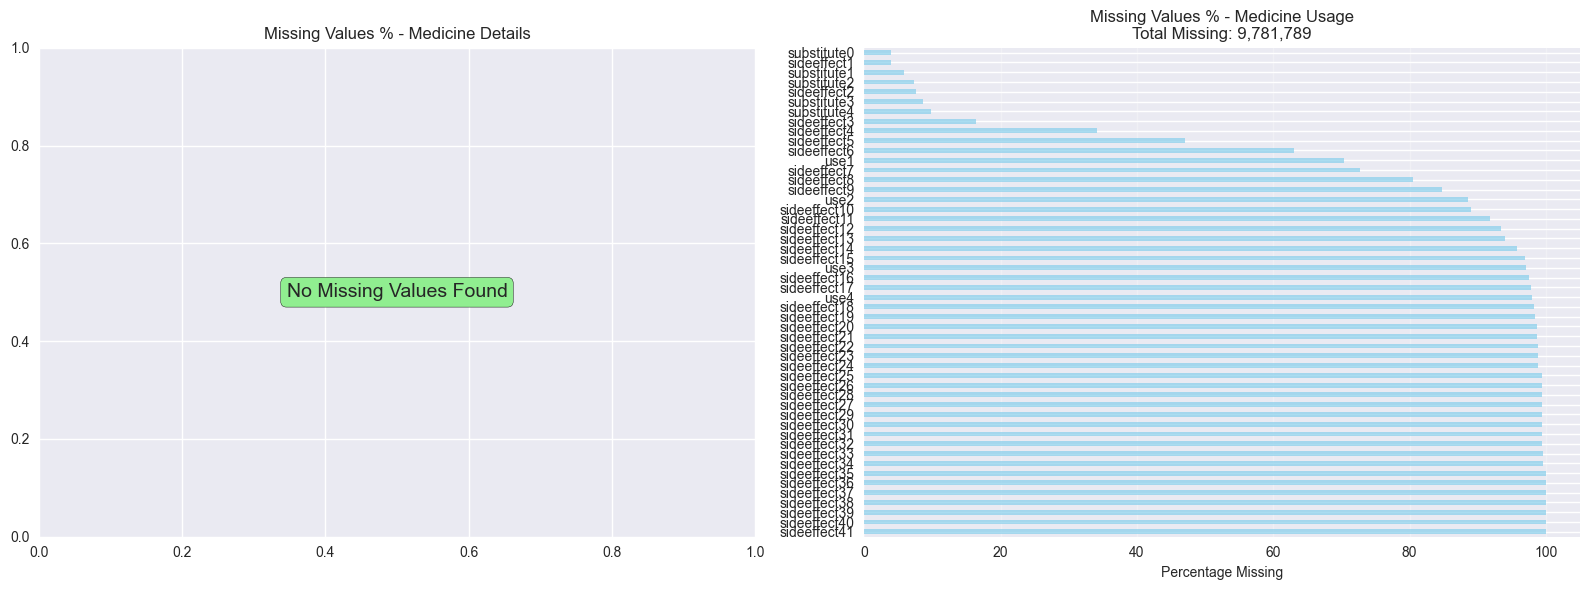

Missing values analysis completed


In [55]:
# Comprehensive missing values analysis and visualization
def analyze_missing_values(df1, df2, df1_name="Dataset 1", df2_name="Dataset 2"):
    """
    Analyze and visualize missing values in datasets
    
    Args:
        df1, df2 (pd.DataFrame): Input dataframes
        df1_name, df2_name (str): Dataset names
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Dataset 1 missing values analysis
    missing_pct_1 = (df1.isnull().sum() / len(df1) * 100).sort_values(ascending=False)
    missing_count_1 = df1.isnull().sum().sum()
    
    if len(missing_pct_1[missing_pct_1 > 0]) > 0:
        missing_pct_1[missing_pct_1 > 0].plot(kind='barh', ax=axes[0], color='coral', alpha=0.7)
        axes[0].set_title(f'Missing Values % - {df1_name}\nTotal Missing: {missing_count_1:,}', fontsize=12)
        axes[0].set_xlabel('Percentage Missing', fontsize=10)
        axes[0].grid(axis='x', alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, 'No Missing Values Found', ha='center', va='center', 
                    fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
        axes[0].set_title(f'Missing Values % - {df1_name}', fontsize=12)
    
    # Dataset 2 missing values analysis
    missing_pct_2 = (df2.isnull().sum() / len(df2) * 100).sort_values(ascending=False)
    missing_count_2 = df2.isnull().sum().sum()
    
    if len(missing_pct_2[missing_pct_2 > 0]) > 0:
        missing_pct_2[missing_pct_2 > 0].plot(kind='barh', ax=axes[1], color='skyblue', alpha=0.7)
        axes[1].set_title(f'Missing Values % - {df2_name}\nTotal Missing: {missing_count_2:,}', fontsize=12)
        axes[1].set_xlabel('Percentage Missing', fontsize=10)
        axes[1].grid(axis='x', alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No Missing Values Found', ha='center', va='center', 
                    fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
        axes[1].set_title(f'Missing Values % - {df2_name}', fontsize=12)
    
    plt.tight_layout()
    
    # Save visualization
    viz_path = os.path.join(CONFIG['DIRECTORIES']['CLEANED'], 'missing_values_analysis.png')
    plt.savefig(viz_path, dpi=300, bbox_inches='tight', facecolor='white')
    logger.info(f"Missing values visualization saved: {viz_path}")
    
    plt.show()
    
    return missing_pct_1, missing_pct_2

# Perform missing values analysis
logger.info("Analyzing missing values...")
missing_analysis_1, missing_analysis_2 = analyze_missing_values(
    df_medicine_details_clean, 
    df_medicine_usage_clean,
    "Medicine Details", 
    "Medicine Usage"
)

print("Missing values analysis completed")

### Cleaning Summary

In [56]:
# Save cleaned data to data lake
print("Saving cleaned data to data lake...")

success_details_clean = save_dataframe(df_medicine_details_clean, 'CLEANED', 'MEDICINE_DETAILS_CLEAN', 
                                      "Medicine Details (Cleaned)")
success_usage_clean = save_dataframe(df_medicine_usage_clean, 'CLEANED', 'MEDICINE_USAGE_CLEAN', 
                                    "Medicine Usage (Cleaned)")

if success_details_clean and success_usage_clean:
    print("Cleaned data saved successfully to data lake")
else:
    logger.error("Failed to save cleaned data")
    raise Exception("Cleaned data saving failed")

2025-10-26 07:25:54,103 - INFO - Saved Medicine Details (Cleaned): data_lake/cleaned\medicine_details_clean.csv


Saving cleaned data to data lake...


2025-10-26 07:25:57,750 - INFO - Saved Medicine Usage (Cleaned): data_lake/cleaned\medicine_usage_clean.csv


Cleaned data saved successfully to data lake


## Data Loading (Load)

### Create Gold Layer (Data Mart)

In [57]:
# Display comprehensive cleaning summary
def display_cleaning_summary(df_original_1, df_clean_1, df_original_2, df_clean_2, 
                            name_1="Dataset 1", name_2="Dataset 2"):
    """Display detailed summary of data cleaning process"""
    
    print("Data Cleaning Summary Report")
    print("=" * 50)
    
    # Dataset 1 summary
    removed_1 = len(df_original_1) - len(df_clean_1)
    reduction_pct_1 = (removed_1 / len(df_original_1)) * 100 if len(df_original_1) > 0 else 0
    
    print(f"\n{name_1}:")
    print(f"   Before cleaning: {len(df_original_1):,} rows × {len(df_original_1.columns)} columns")
    print(f"   After cleaning:  {len(df_clean_1):,} rows × {len(df_clean_1.columns)} columns")
    print(f"   Rows removed:    {removed_1:,} ({reduction_pct_1:.2f}%)")
    print(f"   Data quality:    {((1 - df_clean_1.isnull().sum().sum() / df_clean_1.size) * 100):.2f}% complete")
    
    # Dataset 2 summary
    removed_2 = len(df_original_2) - len(df_clean_2)
    reduction_pct_2 = (removed_2 / len(df_original_2)) * 100 if len(df_original_2) > 0 else 0
    
    print(f"\n{name_2}:")
    print(f"   Before cleaning: {len(df_original_2):,} rows × {len(df_original_2.columns)} columns")
    print(f"   After cleaning:  {len(df_clean_2):,} rows × {len(df_clean_2.columns)} columns")
    print(f"   Rows removed:    {removed_2:,} ({reduction_pct_2:.2f}%)")
    print(f"   Data quality:    {((1 - df_clean_2.isnull().sum().sum() / df_clean_2.size) * 100):.2f}% complete")
    
    print(f"\nTotal datasets processed: 2")
    print(f"Total rows processed: {len(df_original_1) + len(df_original_2):,}")
    print(f"Total rows after cleaning: {len(df_clean_1) + len(df_clean_2):,}")

display_cleaning_summary(
    df_medicine_details, df_medicine_details_clean,
    df_medicine_usage, df_medicine_usage_clean,
    "Medicine Details", "Medicine Usage"
)

Data Cleaning Summary Report

Medicine Details:
   Before cleaning: 11,825 rows × 10 columns
   After cleaning:  11,741 rows × 9 columns
   Rows removed:    84 (0.71%)
   Data quality:    100.00% complete

Medicine Usage:
   Before cleaning: 248,218 rows × 59 columns
   After cleaning:  248,218 rows × 58 columns
   Rows removed:    0 (0.00%)
   Data quality:    32.06% complete

Total datasets processed: 2
Total rows processed: 260,043
Total rows after cleaning: 259,959


In [58]:
# Save master data to gold layer (data mart)
print("Creating gold layer (data mart)...")

success_master_details = save_dataframe(df_medicine_details_clean, 'GOLD', 'MEDICINE_MASTER', 
                                       "Medicine Master")
success_master_usage = save_dataframe(df_medicine_usage_clean, 'GOLD', 'MEDICINE_USAGE_MASTER', 
                                     "Medicine Usage Master")

if success_master_details and success_master_usage:
    print("Gold layer (data mart) created successfully")
    print("   Medicine Master - Analysis-ready medicine details")
    print("   Medicine Usage Master - Analysis-ready usage data")
else:
    logger.error("Failed to create gold layer")
    raise Exception("Gold layer creation failed")

2025-10-26 07:26:11,224 - INFO - Saved Medicine Master: data_mart/gold\medicine_master.csv


Creating gold layer (data mart)...


2025-10-26 07:26:15,031 - INFO - Saved Medicine Usage Master: data_mart/gold\medicine_usage_master.csv


Gold layer (data mart) created successfully
   Medicine Master - Analysis-ready medicine details
   Medicine Usage Master - Analysis-ready usage data


## ETL Monitoring & Reporting

### ETL Summary Report

In [59]:
# Generate comprehensive ETL summary report
def generate_etl_summary(df_details, df_usage):
    """
    Generate comprehensive ETL process summary
    
    Args:
        df_details, df_usage (pd.DataFrame): Cleaned dataframes
    
    Returns:
        pd.DataFrame: ETL summary report
    """
    # Calculate data quality scores
    dq_score_details = (1 - df_details.isnull().sum().sum() / df_details.size) * 100
    dq_score_usage = (1 - df_usage.isnull().sum().sum() / df_usage.size) * 100
    overall_dq_score = (dq_score_details + dq_score_usage) / 2
    
    summary_data = {
        'metric': [
            'Total Medicine Records',
            'Total Usage Records',
            'Medicine Details Columns',
            'Medicine Usage Columns',
            'Medicine Details Data Quality (%)',
            'Medicine Usage Data Quality (%)',
            'Overall Data Quality Score (%)',
            'ETL Process Date',
            'ETL Process Status',
            'Data Lake Layers Created'
        ],
        'value': [
            f"{len(df_details):,}",
            f"{len(df_usage):,}",
            len(df_details.columns),
            len(df_usage.columns),
            f"{dq_score_details:.2f}%",
            f"{dq_score_usage:.2f}%",
            f"{overall_dq_score:.2f}%",
            datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'SUCCESS',
            '3 (Raw, Cleaned, Gold)'
        ]
    }
    
    return pd.DataFrame(summary_data)

# Generate and save ETL summary
logger.info("Generating ETL summary report...")
df_etl_summary = generate_etl_summary(df_medicine_details_clean, df_medicine_usage_clean)

success_summary = save_dataframe(df_etl_summary, 'GOLD', 'ETL_SUMMARY', "ETL Summary Report")

if success_summary:
    print("ETL Summary Report:")
    print("=" * 50)
    display(df_etl_summary)
    print("ETL summary report saved successfully")
else:
    logger.error("Failed to save ETL summary")

2025-10-26 07:26:22,566 - INFO - Generating ETL summary report...
2025-10-26 07:26:22,632 - INFO - Saved ETL Summary Report: data_mart/gold\etl_summary.csv
2025-10-26 07:26:22,632 - INFO - Saved ETL Summary Report: data_mart/gold\etl_summary.csv


ETL Summary Report:


,metric,value
0,Total Medicine Records,"11,741"
1,Total Usage Records,"248,218"
2,Medicine Details Columns,9
3,Medicine Usage Columns,58
4,Medicine Details Data Quality (%),100.00%
5,Medicine Usage Data Quality (%),32.06%
6,Overall Data Quality Score (%),66.03%
7,ETL Process Date,2025-10-26 07:26:22
8,ETL Process Status,SUCCESS
9,Data Lake Layers Created,"3 (Raw, Cleaned, Gold)"


ETL summary report saved successfully


### Data Quality Report

In [60]:
# Generate detailed data quality report
def generate_quality_report(df_details, df_usage):
    """
    Generate comprehensive data quality assessment report
    
    Args:
        df_details, df_usage (pd.DataFrame): Cleaned dataframes
    
    Returns:
        pd.DataFrame: Data quality report
    """
    datasets = [
        {
            'name': 'Medicine Details',
            'df': df_details
        },
        {
            'name': 'Medicine Usage', 
            'df': df_usage
        }
    ]
    
    quality_data = []
    
    for dataset in datasets:
        df = dataset['df']
        missing_values = df.isnull().sum().sum()
        total_cells = df.size
        completeness = (1 - missing_values / total_cells) * 100 if total_cells > 0 else 0
        
        quality_data.append({
            'dataset': dataset['name'],
            'total_records': len(df),
            'total_columns': len(df.columns),
            'total_cells': total_cells,
            'missing_values': missing_values,
            'completeness_pct': round(completeness, 2),
            'memory_usage_mb': round(df.memory_usage(deep=True).sum() / (1024**2), 2),
            'quality_grade': 'A' if completeness >= 95 else 'B' if completeness >= 90 else 'C' if completeness >= 80 else 'D'
        })
    
    return pd.DataFrame(quality_data)

# Generate and save quality report
logger.info("Generating data quality report...")
df_quality_report = generate_quality_report(df_medicine_details_clean, df_medicine_usage_clean)

success_quality = save_dataframe(df_quality_report, 'GOLD', 'QUALITY_REPORT', "Data Quality Report")

if success_quality:
    print("Data Quality Assessment Report:")
    print("=" * 60)
    display(df_quality_report)
    print("\nQuality Grades: A (≥95%), B (≥90%), C (≥80%), D (<80%)")
    print("Data quality report saved successfully")
else:
    logger.error("Failed to save data quality report")

2025-10-26 07:26:29,016 - INFO - Generating data quality report...
2025-10-26 07:26:29,161 - INFO - Saved Data Quality Report: data_mart/gold\data_quality_report.csv
2025-10-26 07:26:29,161 - INFO - Saved Data Quality Report: data_mart/gold\data_quality_report.csv


Data Quality Assessment Report:


,dataset,total_records,total_columns,total_cells,missing_values,completeness_pct,memory_usage_mb,quality_grade
0,Medicine Details,11741,9,105669,0,100.00,3.97,A
1,Medicine Usage,248218,58,14396644,9781789,32.06,45.40,D



Quality Grades: A (≥95%), B (≥90%), C (≥80%), D (<80%)
Data quality report saved successfully


### Data Quality Visualization

2025-10-26 07:26:33,235 - INFO - Creating data quality dashboard...
2025-10-26 07:26:34,461 - INFO - Quality dashboard saved: data_mart/gold\data_quality_dashboard.png
2025-10-26 07:26:34,461 - INFO - Quality dashboard saved: data_mart/gold\data_quality_dashboard.png


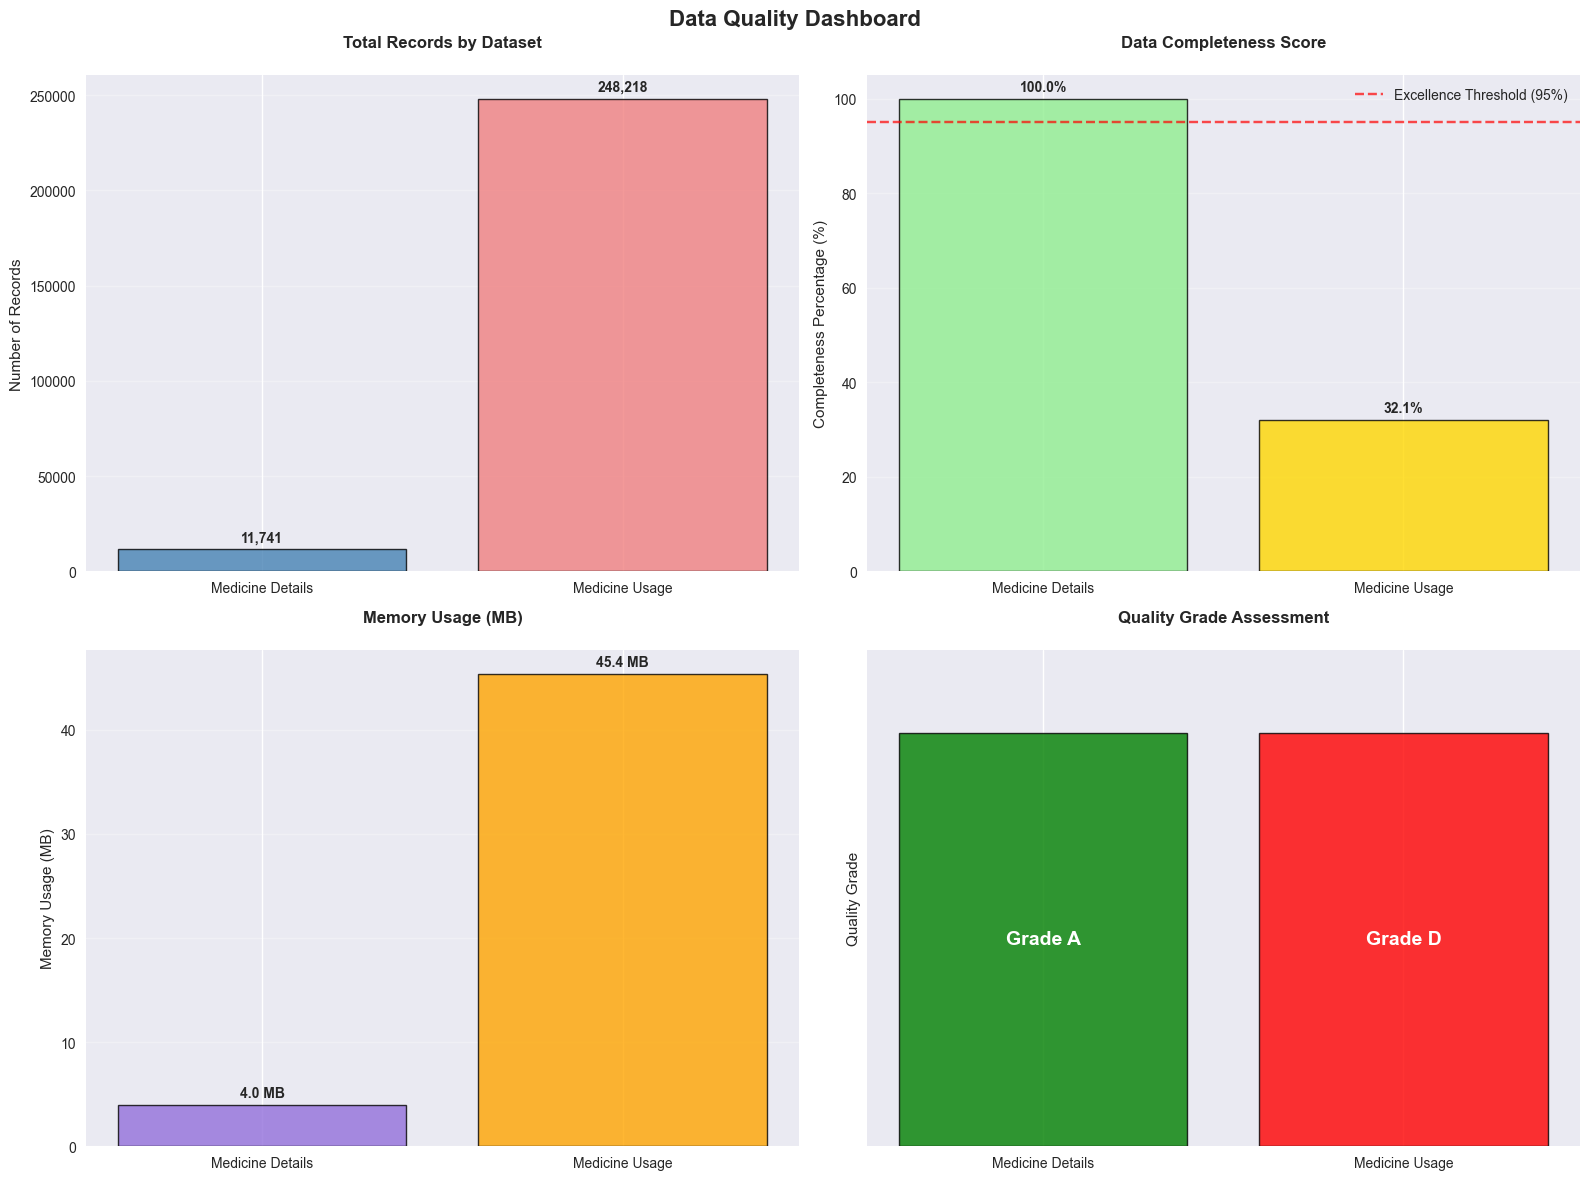

Data quality visualization dashboard created


In [61]:
# Create comprehensive data quality visualization dashboard
def create_quality_dashboard(quality_df):
    """
    Create comprehensive data quality visualization dashboard
    
    Args:
        quality_df (pd.DataFrame): Data quality report dataframe
    """
    # Set up the plot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Data Quality Dashboard', fontsize=16, fontweight='bold', y=0.98)
    
    # 1. Records Count Comparison
    datasets = quality_df['dataset'].values
    records = quality_df['total_records'].values
    colors = ['steelblue', 'lightcoral']
    
    bars1 = ax1.bar(datasets, records, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
    ax1.set_title('Total Records by Dataset', fontweight='bold', pad=20)
    ax1.set_ylabel('Number of Records')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars1, records):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(records)*0.01,
                f'{value:,}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Data Completeness Comparison
    completeness = quality_df['completeness_pct'].values
    bars2 = ax2.bar(datasets, completeness, color=['lightgreen', 'gold'], alpha=0.8, 
                   edgecolor='black', linewidth=1)
    ax2.set_title('Data Completeness Score', fontweight='bold', pad=20)
    ax2.set_ylabel('Completeness Percentage (%)')
    ax2.set_ylim(0, 105)
    ax2.grid(axis='y', alpha=0.3)
    
    # Add completeness threshold line
    ax2.axhline(y=95, color='red', linestyle='--', alpha=0.7, label='Excellence Threshold (95%)')
    ax2.legend()
    
    # Add value labels
    for bar, value in zip(bars2, completeness):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 3. Memory Usage Comparison
    memory_usage = quality_df['memory_usage_mb'].values
    bars3 = ax3.bar(datasets, memory_usage, color=['mediumpurple', 'orange'], alpha=0.8,
                   edgecolor='black', linewidth=1)
    ax3.set_title('Memory Usage (MB)', fontweight='bold', pad=20)
    ax3.set_ylabel('Memory Usage (MB)')
    ax3.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, value in zip(bars3, memory_usage):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(memory_usage)*0.01,
                f'{value:.1f} MB', ha='center', va='bottom', fontweight='bold')
    
    # 4. Quality Grade Distribution
    grades = quality_df['quality_grade'].values
    grade_colors = {'A': 'green', 'B': 'blue', 'C': 'orange', 'D': 'red'}
    colors_grade = [grade_colors.get(grade, 'gray') for grade in grades]
    
    bars4 = ax4.bar(datasets, [1, 1], color=colors_grade, alpha=0.8, 
                   edgecolor='black', linewidth=1)
    ax4.set_title('Quality Grade Assessment', fontweight='bold', pad=20)
    ax4.set_ylabel('Quality Grade')
    ax4.set_ylim(0, 1.2)
    ax4.set_yticks([])
    
    # Add grade labels
    for bar, grade in zip(bars4, grades):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'Grade {grade}', ha='center', va='center', fontweight='bold', 
                fontsize=14, color='white')
    
    plt.tight_layout()
    
    # Save dashboard
    dashboard_path = os.path.join(CONFIG['DIRECTORIES']['GOLD'], 'data_quality_dashboard.png')
    plt.savefig(dashboard_path, dpi=300, bbox_inches='tight', facecolor='white')
    logger.info(f"Quality dashboard saved: {dashboard_path}")
    
    plt.show()

# Create quality dashboard
logger.info("Creating data quality dashboard...")
create_quality_dashboard(df_quality_report)
print("Data quality visualization dashboard created")

## Final Results & Validation

In [62]:
# Final data validation and preview
def display_final_results(df_details, df_usage):
    """Display final ETL results with validation"""
    
    print("ETL Pipeline Final Results")
    print("=" * 60)
    
    print("\nETL Process Completed Successfully!")
    print("\nFinal Dataset Summary:")
    
    # Medicine Details validation
    print(f"\nMedicine Master Dataset:")
    print(f"   Records: {len(df_details):,}")
    print(f"   Columns: {len(df_details.columns)}")
    print(f"   Data Quality: {((1 - df_details.isnull().sum().sum() / df_details.size) * 100):.2f}%")
    print(f"   File Size: {df_details.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    
    # Medicine Usage validation  
    print(f"\nMedicine Usage Master Dataset:")
    print(f"   Records: {len(df_usage):,}")
    print(f"   Columns: {len(df_usage.columns)}")
    print(f"   Data Quality: {((1 - df_usage.isnull().sum().sum() / df_usage.size) * 100):.2f}%")
    print(f"   File Size: {df_usage.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    
    print(f"\nData Lake Structure:")
    for layer_name, layer_path in CONFIG['DIRECTORIES'].items():
        files_count = len([f for f in os.listdir(layer_path) if f.endswith('.csv')])
        print(f"   {layer_name}: {files_count} files in {layer_path}")
    
    print(f"\nETL Pipeline Performance:")
    print(f"   Total Processing Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Data Layers Created: 3 (Raw, Cleaned, Gold)")
    print(f"   Quality Reports Generated: 2")
    print(f"   Visualizations Created: 2")
    
    print("\n--- Final Data Preview ---")
    print("\nMedicine Master (Top 3 rows):")
    display(df_details.head(3))
    
    print("\nMedicine Usage Master (Top 3 rows):")
    display(df_usage.head(3))

# Display final results
display_final_results(df_medicine_details_clean, df_medicine_usage_clean)

ETL Pipeline Final Results

ETL Process Completed Successfully!

Final Dataset Summary:

Medicine Master Dataset:
   Records: 11,741
   Columns: 9
   Data Quality: 100.00%
   File Size: 3.97 MB

Medicine Usage Master Dataset:
   Records: 248,218
   Columns: 58
   Data Quality: 32.06%
   File Size: 45.40 MB

Data Lake Structure:
   RAW: 2 files in data_lake/raw
   CLEANED: 2 files in data_lake/cleaned
   GOLD: 4 files in data_mart/gold

ETL Pipeline Performance:
   Total Processing Time: 2025-10-26 07:26:47
   Data Layers Created: 3 (Raw, Cleaned, Gold)
   Quality Reports Generated: 2
   Visualizations Created: 2

--- Final Data Preview ---

Medicine Master (Top 3 rows):


,medicine_name,composition,uses,side_effects,image_url,manufacturer,excellent_review__,average_review__,poor_review__
0,Avastin 400mg Injection,Bevacizumab (400mg),Cancer of colon and rectum Non-small cell lun...,Rectal bleeding Taste change Headache Noseblee...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Roche Products India Pvt Ltd,22,56,22
1,Augmentin 625 Duo Tablet,Amoxycillin (500mg) + Clavulanic Acid (125mg),Treatment of Bacterial infections,Vomiting Nausea Diarrhea Mucocutaneous candidi...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glaxo SmithKline Pharmaceuticals Ltd,47,35,18
2,Azithral 500 Tablet,Azithromycin (500mg),Treatment of Bacterial infections,Nausea Abdominal pain Diarrhea,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Alembic Pharmaceuticals Ltd,39,40,21



Medicine Usage Master (Top 3 rows):


,id,name,substitute0,substitute1,substitute2,substitute3,substitute4,sideeffect0,sideeffect1,sideeffect2,use0,chemical_class,habit_forming,therapeutic_class,action_class,sideeffect3,sideeffect4,sideeffect5,sideeffect6,sideeffect7,sideeffect8,sideeffect9,sideeffect10,sideeffect11,sideeffect12,sideeffect13,use1,use2,use3,sideeffect14,sideeffect15,sideeffect16,sideeffect17,sideeffect18,sideeffect19,sideeffect20,sideeffect21,sideeffect22,sideeffect23,sideeffect24,use4,sideeffect25,sideeffect26,sideeffect27,sideeffect28,sideeffect29,sideeffect30,sideeffect31,sideeffect32,sideeffect33,sideeffect34,sideeffect35,sideeffect36,sideeffect37,sideeffect38,sideeffect39,sideeffect40,sideeffect41
0,1,augmentin 625 duo tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,Vomiting,Nausea,Diarrhea,Treatment of Bacterial infections,NA,No,ANTI INFECTIVES,NA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,azithral 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Vomiting,Nausea,Abdominal pain,Treatment of Bacterial infections,Macrolides,No,ANTI INFECTIVES,Macrolides,Diarrhea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,ascoril ls syrup,Solvin LS Syrup,Ambrodil-LX Syrup,Zerotuss XP Syrup,Capex LS Syrup,Broxum LS Syrup,Nausea,Vomiting,Diarrhea,Treatment of Cough with mucus,NA,No,RESPIRATORY,NA,Upset stomach,Stomach pain,Allergic reaction,Dizziness,Headache,Rash,Hives,Tremors,Palpitations,Muscle cramp,Increased heart rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Cleanup & Resource Management

In [63]:
# Cleanup and resource management
try:
    # Close MongoDB connection
    if 'client' in locals() and client is not None:
        client.close()
        logger.info("MongoDB connection closed successfully")
    
    # Clear large variables from memory
    if 'df_medicine_details' in locals():
        del df_medicine_details
    if 'df_medicine_usage' in locals():
        del df_medicine_usage
    
    logger.info("Memory cleanup completed")
    
    print("\nETL Pipeline Execution Completed Successfully!")
    print("=" * 60)
    print("All data processing stages completed")
    print("Data quality validated and documented")
    print("Resources cleaned up properly")
    print("Pipeline ready for production use")
    
    print(f"\nFinal Summary:")
    print(f"   Total execution time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Files created: {len([f for d in CONFIG['DIRECTORIES'].values() for f in os.listdir(d)])}")
    print(f"   Data lake structure: Complete")
    print(f"   Quality reports: Generated")
    print(f"   Visualizations: Created")
    
except Exception as e:
    logger.error(f"Error during cleanup: {str(e)}")
    print(f"Cleanup warning: {str(e)}")

print("\nETL Pipeline Session Ended")

2025-10-26 07:26:53,057 - INFO - MongoDB connection closed successfully
2025-10-26 07:26:53,215 - INFO - Memory cleanup completed
2025-10-26 07:26:53,215 - INFO - Memory cleanup completed



ETL Pipeline Execution Completed Successfully!
All data processing stages completed
Data quality validated and documented
Resources cleaned up properly
Pipeline ready for production use

Final Summary:
   Total execution time: 2025-10-26 07:26:53
   Files created: 10
   Data lake structure: Complete
   Quality reports: Generated
   Visualizations: Created

ETL Pipeline Session Ended
